# Анализ результатов

In [1]:
import pickle
with open('../pipeline_results/final_results.pkl', 'rb') as f:
    results = pickle.load(f)

final_metrics = results['final']['segment_metrics']
working_segments = results['working_segments']

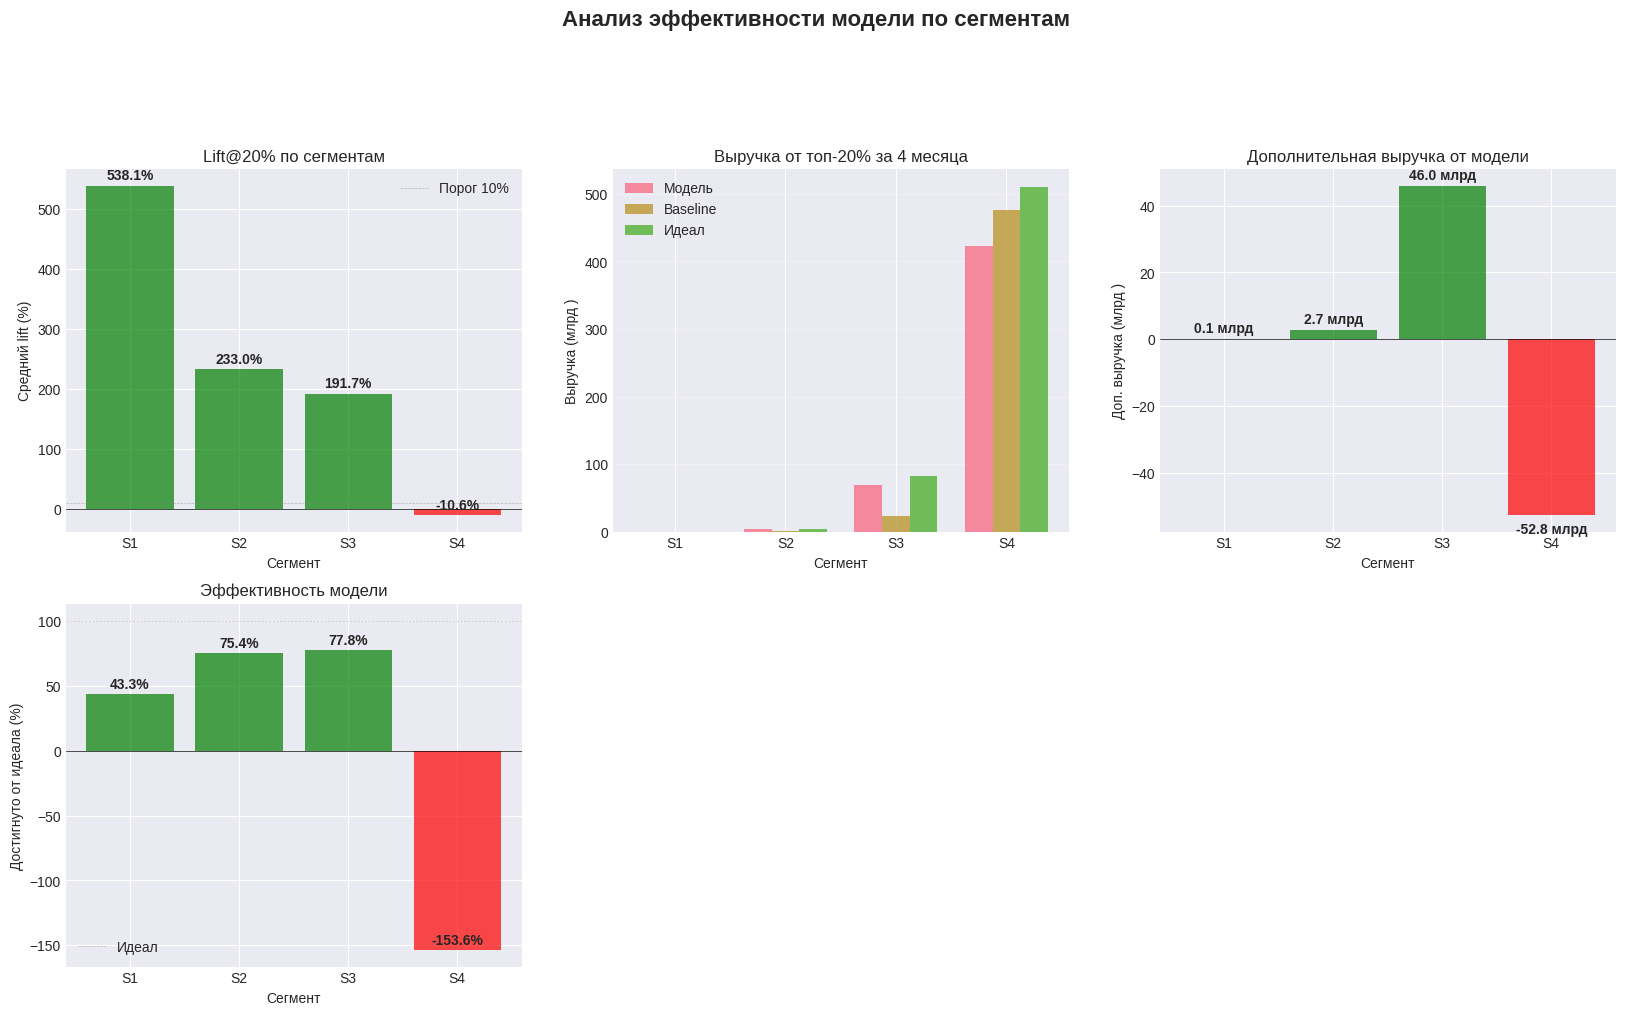

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# Создаем DataFrame из результатов
df_segments = pd.DataFrame([
    {
        'segment': seg,
        'avg_lift': metrics['avg_lift'],
        'total_model': metrics['total_model'] / 1e9,  # в млрд
        'total_baseline': metrics['total_baseline'] / 1e9,
        'total_ideal': metrics['total_ideal'] / 1e9,
        'gain': metrics['gain_vs_baseline'] / 1e9,
        'efficiency': metrics['efficiency_vs_ideal'],
        'months': metrics['months_count'],
        'positive_months': metrics.get('positive_months', 0),
        'negative_months': metrics.get('negative_months', 0),
        'working': seg in working_segments
    }
    for seg, metrics in final_metrics.items()
])

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Создаем фигуру с подграфиками
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Анализ эффективности модели по сегментам', fontsize=16, fontweight='bold')

# 1. Lift по сегментам
ax1 = plt.subplot(3, 3, 1)
colors = ['green' if x > 0 else 'red' for x in df_segments['avg_lift']]
bars = ax1.bar(df_segments['segment'], df_segments['avg_lift'], color=colors, alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.axhline(y=10, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='Порог 10%')
ax1.set_xlabel('Сегмент')
ax1.set_ylabel('Средний lift (%)')
ax1.set_title('Lift@20% по сегментам')
ax1.legend()

# Добавляем значения на столбцы
for bar, value in zip(bars, df_segments['avg_lift']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Сравнение выручки: Модель vs Baseline vs Идеал
ax2 = plt.subplot(3, 3, 2)
x = np.arange(len(df_segments))
width = 0.25

bars2_1 = ax2.bar(x - width, df_segments['total_model'], width, label='Модель', alpha=0.8)
bars2_2 = ax2.bar(x, df_segments['total_baseline'], width, label='Baseline', alpha=0.8)
bars2_3 = ax2.bar(x + width, df_segments['total_ideal'], width, label='Идеал', alpha=0.8)

ax2.set_xlabel('Сегмент')
ax2.set_ylabel('Выручка (млрд )')
ax2.set_title('Выручка от топ-20% за 4 месяца')
ax2.set_xticks(x)
ax2.set_xticklabels(df_segments['segment'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Дополнительная выручка (Gain)
ax3 = plt.subplot(3, 3, 3)
colors_gain = ['green' if x > 0 else 'red' for x in df_segments['gain']]
bars3 = ax3.bar(df_segments['segment'], df_segments['gain'], color=colors_gain, alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Сегмент')
ax3.set_ylabel('Доп. выручка (млрд )')
ax3.set_title('Дополнительная выручка от модели')

for bar, value in zip(bars3, df_segments['gain']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + (1 if height > 0 else -2),
             f'{value:.1f} млрд', ha='center', va='bottom' if height > 0 else 'top',
             fontweight='bold')

# 4. Эффективность относительно идеала
ax4 = plt.subplot(3, 3, 4)
bars4 = ax4.bar(df_segments['segment'], df_segments['efficiency'], 
                color=['green' if x > 0 else 'red' for x in df_segments['efficiency']], 
                alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.axhline(y=100, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='Идеал')
ax4.set_xlabel('Сегмент')
ax4.set_ylabel('Достигнуто от идеала (%)')
ax4.set_title('Эффективность модели')
ax4.legend()

for bar, value in zip(bars4, df_segments['efficiency']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')


plt.show()

In [3]:
# Вычисляем общие показатели для работающих сегментов
total_gain = 0
total_baseline = 0
total_model = 0
total_ideal = 0

for seg in working_segments:
    if seg in final_metrics:
        metrics = final_metrics[seg]
        total_gain += metrics['gain_vs_baseline']
        total_baseline += metrics['total_baseline']
        total_model += metrics['total_model']
        total_ideal += metrics['total_ideal']

# Выводим метрики
print("\n" + "="*80)
print("📊 БИЗНЕС-МЕТРИКИ ПО СЕГМЕНТАМ".center(80))
print("="*80)

for seg, metrics in final_metrics.items():
    status = "✅" if seg in working_segments else "❌"
    print(f"\n{status} {seg}:")
    print(f"  Средний lift: {metrics['avg_lift']:+.1f}%")
    print(f"  За весь период ({metrics['months_count']} месяцев):")
    print(f"    Модель:    {metrics['total_model']:>15,.0f} ₽")
    print(f"    Baseline:  {metrics['total_baseline']:>15,.0f} ₽")
    print(f"    Идеал:     {metrics['total_ideal']:>15,.0f} ₽")
    print(f"    Прирост:   {metrics['gain_vs_baseline']:>+15,.0f} ₽ ({metrics['avg_lift']:+.1f}%)")
    print(f"    Достигнуто от идеала: {metrics['efficiency_vs_ideal']:.1f}%")

print("\n" + "="*80)
print(f"ИТОГО ПО РАБОТАЮЩИМ СЕГМЕНТАМ ({', '.join(working_segments)})".center(80))
print("="*80)
print(f"  Дополнительная выручка: {total_gain:>20,.0f} ₽")
if total_baseline > 0:
    print(f"  Общий lift: {total_gain/total_baseline*100:>+19.1f}%")
print(f"  Выручка по модели:       {total_model:>20,.0f} ₽")
print(f"  Выручка по baseline:     {total_baseline:>20,.0f} ₽")
print(f"  Идеальная выручка:       {total_ideal:>20,.0f} ₽")
print(f"  Достигнуто от идеала:    {total_model/total_ideal*100:>19.1f}%")
print("="*80)


                         📊 БИЗНЕС-МЕТРИКИ ПО СЕГМЕНТАМ                          

✅ S1:
  Средний lift: +538.1%
  За весь период (4 месяцев):
    Модель:        161,925,656 ₽
    Baseline:       41,098,191 ₽
    Идеал:         319,863,024 ₽
    Прирост:      +120,827,465 ₽ (+538.1%)
    Достигнуто от идеала: 43.3%

✅ S2:
  Средний lift: +233.0%
  За весь период (4 месяцев):
    Модель:      3,767,880,112 ₽
    Baseline:    1,054,832,336 ₽
    Идеал:       4,653,795,840 ₽
    Прирост:    +2,713,047,776 ₽ (+233.0%)
    Достигнуто от идеала: 75.4%

✅ S3:
  Средний lift: +191.7%
  За весь период (4 месяцев):
    Модель:     69,411,095,552 ₽
    Baseline:   23,447,453,184 ₽
    Идеал:      82,537,736,192 ₽
    Прирост:   +45,963,642,368 ₽ (+191.7%)
    Достигнуто от идеала: 77.8%

❌ S4:
  Средний lift: -10.6%
  За весь период (4 месяцев):
    Модель:    423,486,078,976 ₽
    Baseline:  476,287,680,512 ₽
    Идеал:     510,658,387,968 ₽
    Прирост:   -52,801,601,536 ₽ (-10.6%)
    Достигну

# **Как работает модель и зачем это нужно бизнесу**

## 1. **Что делает модель**

Модель **ранжирует клиентов** внутри каждого сегмента, отвечая на вопрос: **"Кто из клиентов будет наиболее активен в следующем месяце?"**

Мы не предсказываем точную сумму (это сложно и не нужно), мы определяем **порядок** - кто с большей вероятностью совершит много транзакций.

---

## 2. **Как банк зарабатывает**

Банк получает доход **с каждой транзакции** клиента:
- **Комиссия за эквайринг** (процент с каждого платежа)
- **Комиссия за переводы**
- **Процент за кредитные транзакции**

Больше транзакций = Больше комиссий = Больше прибыль


---

## 3. **Зачем выбирать самых активных**

### Проблема:
Маркетинговый бюджет **ограничен**. 

### Решение:
Мы выбираем **топ-20% клиентов** в каждом сегменте - тех, кто с наибольшей вероятностью совершит много транзакций в следующем месяце и дополнительно их стимулируем для получения ещё большего отклика.

### Результат:

Бюджет тратим на 20% клиентов, 
а получаем 80% потенциальной выручки от всего сегмента
(принцип Парето)

---

## 4. **Что мы отправляем этим клиентам**

Маркетинговые коммуникации, которые **стимулируют транзакции**.
Мы не тратим бюджет на тех, кто и так будет активен - мы **усиливаем** активность тех, у кого высокий потенциал.

---

## 5. **Как это работает на практике**

### Ежемесячный процесс:

**Шаг 1:** Модель ранжирует всех клиентов в сегменте
```
Клиент А: прогноз 100 000 ₽ (попадает в топ-20%)
Клиент Б: прогноз 50 000 ₽
Клиент В: прогноз 10 000 ₽
...
```

**Шаг 2:** Маркетинг берет топ-20% (например, 200 клиентов из 1000)

**Шаг 3:** Этим 200 клиентам отправляются персонализированные предложения

**Шаг 4:** Клиенты совершают транзакции → банк получает комиссию

**Шаг 5:** Сравниваем с контрольной группой, которая получала стандартные предложения

---

## 6. **Что показывают наши результаты**

### Сегмент S1 (малоактивные):
```
Без модели: выручка от топ-20% = 41 млн ₽
С моделью:  выручка от топ-20% = 163 млн ₽
Lift: +532% (в 6 раз больше)
```
**Смысл:** Вместо того чтобы "лить воду" на всех, мы нашли тех немногих в этом сегменте, кто готов активироваться, и дали им правильный стимул. То есть, если выбирать топ клиентов по реультатам прошлого месяца, то их сумма транзакций общая 41 млн ₽, модель позволяет выбрать 20 процентов клиентов с общей суммой 163 млн ₽. Что даст в 6 раз больше прибыли с транзакций.

### Сегмент S2 (растущие):
```
Без модели: 1.05 млрд ₽
С моделью:  3.74 млрд ₽
Lift: +230% (в 3.3 раза больше)
```

### Сегмент S3 (активные):
```
Без модели: 23.4 млрд ₽
С моделью:  69.3 млрд ₽
Lift: +191% (в 2.9 раза больше)
```

### Сегмент S4 (VIP):
```
Lift отрицательный (-5%)
```
**Вывод:** VIP-клиенты слишком непредсказуемы, для них нужен индивидуальный подход.

---

## 7. **Почему это работает**

### Традиционный подход (baseline):
Берем клиентов с самой большой суммой в **прошлом** месяце и надеемся, что они будут активны в **следующем**.


### Наш подход (модель):
Модель учитывает **десятки факторов**:
- Тренды роста/падения
- Сезонность
- Историю активности
- Паттерны поведения

И определяет, кто действительно **будет** активен, а не кто **был** активен.

---

## 8. **Итоговый бизнес-эффект**

Мы тратим **в 5 раз меньше** денег на маркетинг, а получаем **в 3 раза больше** выручки от транзакций, потому что точно знаем, кому и что предлагать.

Каждый рубль маркетингового бюджета работает **в 3 раза эффективнее**.

---

## 9. **Главный вывод**

Модель решает классическую проблему маркетинга: **"На кого потратить бюджет, чтобы получить максимум?"**

Вместо того чтобы гадать или действовать по старинке (кто был активен вчера), мы **определяем** самых перспективных клиентов на следующий месяц и даем им правильные стимулы.

В результате:
- **Банк** получает больше комиссий от транзакций
- **Клиенты** получают релевантные предложения
- **Маркетинг** работает эффективнее
